In [1]:
import pandas as pd
import glob
import os

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
import ixmp as ix
import message_ix
import pandas as pd

pd.options.display.float_format = "{:,.1f}".format
import warnings

warnings.filterwarnings("ignore")

In [3]:
DP_MAP = {
    2025: 5,
    2030: 5,
    2035: 5,
    2040: 5,
    2045: 5,
    2050: 5,
    2055: 5,
    2060: 10,
    2070: 10,
}

print(DP_MAP)

{2025: 5, 2030: 5, 2035: 5, 2040: 5, 2045: 5, 2050: 5, 2055: 5, 2060: 10, 2070: 10}


In [49]:
df = pd.read_excel("D:/COMMITTED/Models/NEST-Pakistan/submission3/CurPol.xlsx")

In [50]:
emiss_co2 = df[df["Variable"]=="Emissions|CO2|Energy"]

In [51]:
emiss_co2 = emiss_co2.T.reset_index()

In [52]:
emiss_co2

,index,111
0,2025,225.1
1,2030,260.8
2,2035,352.1
3,2040,449.4
4,2045,656.5
5,2050,592.7
6,2055,841.2
7,2060,741.1
8,2070,"1,353.6"
9,Model,MESSAGEix-Pakistan 1


In [57]:
emiss_co2 = emiss_co2.rename(columns={'index':'year',111:'value'}).iloc[0:9]

In [58]:
emiss_co2["period"] = emiss_co2["year"].map(DP_MAP)

In [64]:
emiss_co2["CO2_emiss"] = (emiss_co2["value"] * emiss_co2["period"]) / 1000

In [66]:
op = emiss_co2["CO2_emiss"].sum()

In [67]:
op

37.83787983842943

<Axes: xlabel='Bound', ylabel='Budget'>

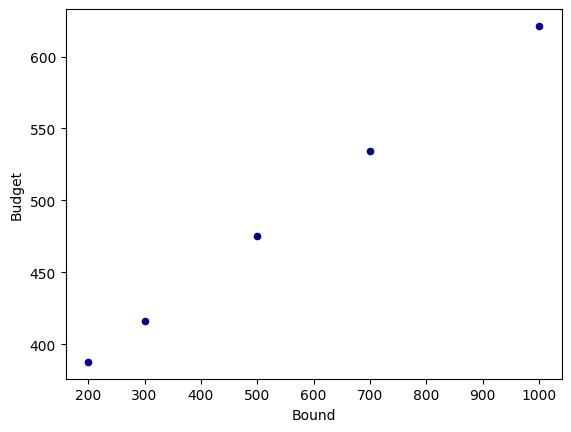

In [71]:
import pandas as pd
df=pd.read_csv("D:/COMMITTED/Models/NEST-Pakistan/modelData/emissionAllocation/bound_budget_indc_weak_forever.csv")
df.sort_values(by="Bound").plot.scatter(x="Bound", y="Budget", c="DarkBlue")

In [ ]:
import numpy as np
from sklearn import datasets, linear_model
import matplotlib.pyplot as plt

x = df.Budget.values.reshape(-1, 1)
y = df.Bound.values.reshape(-1, 1)

regr = linear_model.LinearRegression()
regr.fit(x, y)
print(regr.coef_)
print(regr.intercept_)

for budget in [
    200,
    250,
    300,
    320,
    350,
    400,
    450,
    500,
    550,
    570,
    580,
    590,
    600,
    650,
    700,
    750,
    800,
    850,
    900,
    950,
    1000,
    1100,
    1200,
    1300,
    1400,
    1500,
    1600,
    1700,
    1800,
    1900,
    2000,
    2100,
    2200,
    2300,
    2400,
    2500,
    2600,
    2700,
    2800,
    2900,
    3000,
    4000,
]:
    print(
        "Budget (GTCO2) : ",
        budget,
        ",     Bound (MT C) : ",
        round(regr.predict(np.array([[budget]]))[0][0], 2),
    )

[[3.41805512]]
[-1124.07813359]
Budget (GTCO2) :  200 ,     Bound (MT C) :  -440.467109521
Budget (GTCO2) :  250 ,     Bound (MT C) :  -269.5643535038
Budget (GTCO2) :  300 ,     Bound (MT C) :  -98.6615974866
Budget (GTCO2) :  320 ,     Bound (MT C) :  -30.3004950797
Budget (GTCO2) :  350 ,     Bound (MT C) :  72.2411585307
Budget (GTCO2) :  400 ,     Bound (MT C) :  243.1439145479
Budget (GTCO2) :  450 ,     Bound (MT C) :  414.0466705651
Budget (GTCO2) :  500 ,     Bound (MT C) :  584.9494265823
Budget (GTCO2) :  550 ,     Bound (MT C) :  755.8521825996
Budget (GTCO2) :  570 ,     Bound (MT C) :  824.2132850064
Budget (GTCO2) :  580 ,     Bound (MT C) :  858.3938362099
Budget (GTCO2) :  590 ,     Bound (MT C) :  892.5743874133
Budget (GTCO2) :  600 ,     Bound (MT C) :  926.7549386168
Budget (GTCO2) :  650 ,     Bound (MT C) :  1097.657694634
Budget (GTCO2) :  700 ,     Bound (MT C) :  1268.5604506512
Budget (GTCO2) :  750 ,     Bound (MT C) :  1439.4632066685
Budget (GTCO2) :  800 

In [89]:
regr.predict(np.array([[op]]))[0][0]

np.float64(-994.7461746651867)